In [1]:
import torch
import torch.nn as nn

from thesis_code.datasets import get_SHD_dataloader
from thesis_code.networks import train, test, models
from thesis_code.plotting import plot_performance

c:\Users\emiel\Documents\Study\Thesis\Thesis-Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [3]:
SHD_trainloader, input_dim, classes = get_SHD_dataloader(
    batch_size=128,
    time_window=10000,
    train=True,
    shuffle=True,
    drop_last=True,
    re_download=False,
)

SHD_testloader, _, _ = get_SHD_dataloader(
    batch_size=128,
    time_window=10000,
    train=False,
    shuffle=True,
    drop_last=True,
    re_download=False,
)

In [4]:
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np

loss_fn = nn.CrossEntropyLoss(reduction='none')

def compute_loss(mem_rec, targets, device):
    loss_val = torch.zeros((1), dtype=torch.float, device=device)
    for mem_out in mem_rec:
        loss_val += loss_fn(mem_out, targets).mean() / len(mem_rec)
    return loss_val

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)
            
            spk_rec, mem_rec = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    loss_hist, acc_hist = [], []
    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)

            spk_rec, mem_rec = net(data)
            loss_val = compute_loss(mem_rec, targets, device)

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist

Test Accuracy before training is: 0.04779411764705882


Epoch 0:   2%|▏         | 1/63 [00:00<00:43,  1.41it/s, acc=1.56%, loss=6.68]

Epoch 0, Iteration 0 — Loss: 6.68, Acc: 1.56%


Epoch 0:  41%|████▏     | 26/63 [00:20<00:31,  1.18it/s, acc=3.91%, loss=3.20] 

Epoch 0, Iteration 25 — Loss: 3.20, Acc: 3.91%


...

Epoch 9, Iteration 25 — Loss: 2.97, Acc: 7.03%


Epoch 9:  81%|████████  | 51/63 [01:03<00:14,  1.23s/it, acc=10.16%, loss=2.94]

Epoch 9, Iteration 50 — Loss: 2.94, Acc: 10.16%


Epoch 9: 100%|██████████| 63/63 [01:18<00:00,  1.25s/it, acc=7.81%, loss=2.98] 


Test Accuracy after training is: 0.11764705882352941


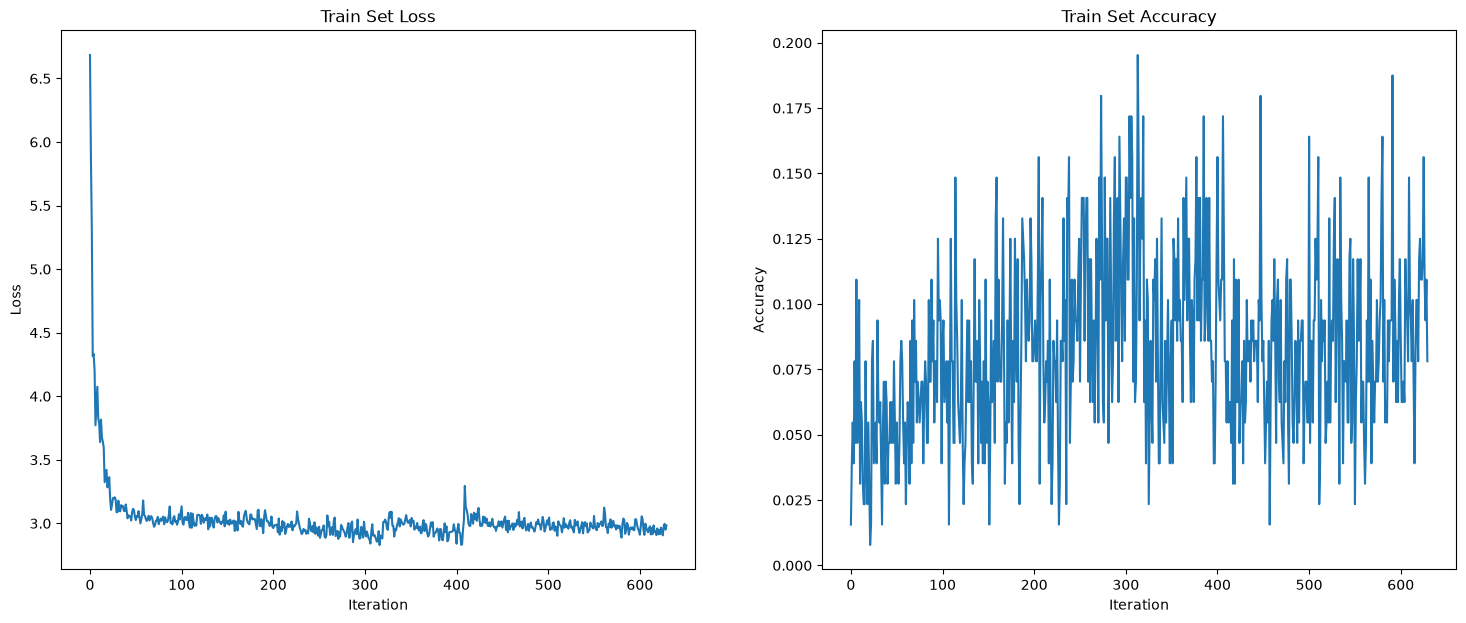

In [6]:
net = models.SynapticSRNN(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    alpha=0.9,
    beta=0.8,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

Test Accuracy before training is: 0.051470588235294115


Epoch 0:   2%|▏         | 1/63 [00:01<01:09,  1.12s/it, acc=7.03%, loss=6.28]

Epoch 0, Iteration 0 — Loss: 6.28, Acc: 7.03%


Epoch 0:  41%|████▏     | 26/63 [00:33<00:44,  1.21s/it, acc=3.91%, loss=3.20]

Epoch 0, Iteration 25 — Loss: 3.20, Acc: 3.91%


...

Epoch 9, Iteration 25 — Loss: 2.89, Acc: 11.72%


Epoch 9:  81%|████████  | 51/63 [00:44<00:10,  1.10it/s, acc=14.06%, loss=2.95]

Epoch 9, Iteration 50 — Loss: 2.95, Acc: 14.06%


Epoch 9: 100%|██████████| 63/63 [00:58<00:00,  1.08it/s, acc=17.97%, loss=2.87]


Test Accuracy after training is: 0.1479779411764706


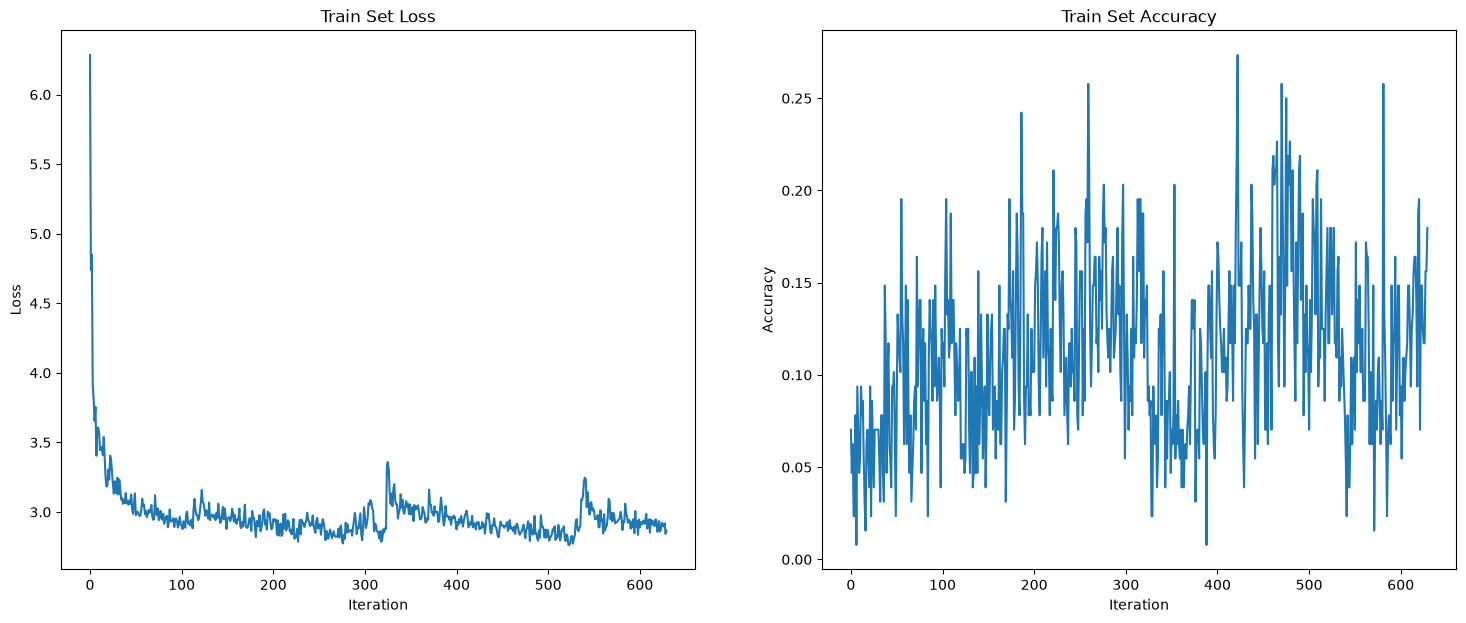

In [7]:
net = models.SynapticSRNN(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    alpha=0.9,
    beta=0.8,
    fully_learnable=True,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

In [5]:
from torch import Tensor

net = models.SynapticSRNN(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    alpha=0.9,
    beta=0.8,
    fully_learnable=True,
).to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=1e-3, betas=(0.9, 0.999))

net.train()
data, targets = next(iter(SHD_trainloader))
data, targets = data.to(device).squeeze(2), targets.to(device)

for i in range(2):
    spk_rec, mem_rec = net(data)
    loss_val = compute_loss(mem_rec, targets, device)
    optimizer.zero_grad()
    loss_val.backward()
    optimizer.step()
    print(f"iter {i} ok")

net.reset()
for name, m in net.net.named_modules():
    for attr in ("mem", "syn", "spk"):
        if hasattr(m, attr) and getattr(m, attr) is not None:
            t = getattr(m, attr)
            print(name, attr, "grad_fn:", t.grad_fn)

def forward(self, data: Tensor) -> tuple[Tensor, Tensor]:
    spk_rec, mem_rec = [], []
    for m in self.net.modules():
        for attr in ("mem", "syn", "spk"):
            if hasattr(m, attr):
                setattr(m, attr, None)

    for step in range(data.size(0)):
        spk_out, mem_out = self.net(data[step])
        spk_rec.append(spk_out)
        mem_rec.append(mem_out)

    return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

iter 0 ok
iter 1 ok
1 mem grad_fn: None
1 syn grad_fn: None
1 spk grad_fn: None
1.neurons mem grad_fn: None
1.neurons syn grad_fn: None
1.neurons spk grad_fn: None
2 mem grad_fn: None
2 syn grad_fn: None
2 spk grad_fn: None
2.neurons mem grad_fn: None
2.neurons syn grad_fn: None
2.neurons spk grad_fn: None
3 mem grad_fn: None
3.neurons mem grad_fn: None
